In [60]:
# import libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler,LabelEncoder 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.svm import SVC
from sklearn.ensemble import ExtraTreesClassifier 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

# Load Dataset

In [61]:
df=pd.read_csv('/Users/manvidhamija/Documents/ai lab/irrigation_prediction.csv')
df.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South,Low
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Canal,Groundwater,12.22,Yes,33.56,Central,Medium
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Rabi,Drip,Reservoir,5.52,Yes,34.62,South,Low
3,Clay,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Wheat,Sowing,Kharif,Canal,Reservoir,1.43,Yes,84.03,North,Medium
4,Clay,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Cotton,Sowing,Zaid,Canal,River,2.52,No,60.86,South,Medium


# Data Preprocessing

In [62]:
# check the shape of dataset
df.shape

(10000, 20)

In [63]:
# check the columns of dataset
df.columns

Index(['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
       'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage',
       'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare',
       'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need'],
      dtype='str')

In [64]:
# checking the null values in dataset
df.isnull().sum()

Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

In [65]:
# checking the duplicated values in datasets 
df.duplicated().sum()

np.int64(0)

# Descriptive Analysis

In [66]:
# info of datasets 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Soil_Type                10000 non-null  str    
 1   Soil_pH                  10000 non-null  float64
 2   Soil_Moisture            10000 non-null  float64
 3   Organic_Carbon           10000 non-null  float64
 4   Electrical_Conductivity  10000 non-null  float64
 5   Temperature_C            10000 non-null  float64
 6   Humidity                 10000 non-null  float64
 7   Rainfall_mm              10000 non-null  float64
 8   Sunlight_Hours           10000 non-null  float64
 9   Wind_Speed_kmh           10000 non-null  float64
 10  Crop_Type                10000 non-null  str    
 11  Crop_Growth_Stage        10000 non-null  str    
 12  Season                   10000 non-null  str    
 13  Irrigation_Type          10000 non-null  str    
 14  Water_Source             10000 non

In [67]:
# statistical summary of dataset 
df.describe()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,6.487857,36.969207,0.944731,1.791963,26.991423,60.080339,1252.499420,7.518538,10.163545,7.598024,59.864122
std,0.979963,16.430845,0.372406,0.984202,8.664074,20.187973,715.582201,2.016077,5.670923,4.233919,34.483722
min,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,5.640000,22.860000,0.620000,0.940000,19.460000,42.855000,634.155000,5.760000,5.160000,3.950000,30.160000
50%,6.470000,37.240000,0.950000,1.780000,27.090000,60.040000,1250.335000,7.560000,10.190000,7.540000,59.630000
75%,7.350000,50.940000,1.260000,2.650000,34.500000,77.705000,1880.265000,9.260000,15.100000,11.202500,90.030000
max,8.200000,65.000000,1.600000,3.500000,42.000000,95.000000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [68]:
df.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South,Low
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Canal,Groundwater,12.22,Yes,33.56,Central,Medium
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Rabi,Drip,Reservoir,5.52,Yes,34.62,South,Low
3,Clay,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Wheat,Sowing,Kharif,Canal,Reservoir,1.43,Yes,84.03,North,Medium
4,Clay,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Cotton,Sowing,Zaid,Canal,River,2.52,No,60.86,South,Medium


In [69]:
# checking the how many types of soil 
df['Soil_Type'].unique()

<ArrowStringArray>
['Clay', 'Silt', 'Sandy', 'Loamy']
Length: 4, dtype: str

In [70]:
# checking the how many values of the each soil type 
df['Soil_Type'].value_counts()

Soil_Type
Sandy    2536
Silt     2501
Loamy    2486
Clay     2477
Name: count, dtype: int64

In [71]:
# checking the types of crop
df['Crop_Type'].unique()

<ArrowStringArray>
['Wheat', 'Maize', 'Cotton', 'Rice', 'Sugarcane', 'Potato']
Length: 6, dtype: str

In [72]:
# know checking the values of each crop types 
df['Crop_Type'].value_counts()

Crop_Type
Rice         1711
Maize        1694
Sugarcane    1678
Potato       1663
Wheat        1659
Cotton       1595
Name: count, dtype: int64

In [73]:
# checking the seasions 
df['Season'].unique()

<ArrowStringArray>
['Rabi', 'Zaid', 'Kharif']
Length: 3, dtype: str

In [74]:
# checking the values of each seasion 
df['Season'].value_counts()

Season
Rabi      3383
Kharif    3362
Zaid      3255
Name: count, dtype: int64

In [75]:
# checking the irrigation types in dataset
df['Irrigation_Type'].unique()

<ArrowStringArray>
['Rainfed', 'Canal', 'Drip', 'Sprinkler']
Length: 4, dtype: str

In [76]:
df["Irrigation_Need"].value_counts()

Irrigation_Need
Low       5864
Medium    3800
High       336
Name: count, dtype: int64

In [77]:
# checking the regions in dataset
df['Region'].unique()

<ArrowStringArray>
['South', 'Central', 'North', 'East', 'West']
Length: 5, dtype: str

In [78]:
# checking the how many type of irrigation need in datasets
df['Irrigation_Need'].unique()

<ArrowStringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

In [79]:
# separate the numerical and categorical columns 
numerical_cols = [
    'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
    'Electrical_Conductivity', 'Temperature_C', 'Humidity',
    'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh',
    'Field_Area_hectare', 'Previous_Irrigation_mm'
]

categorical_cols = [
    'Soil_Type', 'Crop_Type', 'Crop_Growth_Stage',
    'Season', 'Irrigation_Type', 'Water_Source',
    'Mulching_Used', 'Region'
]

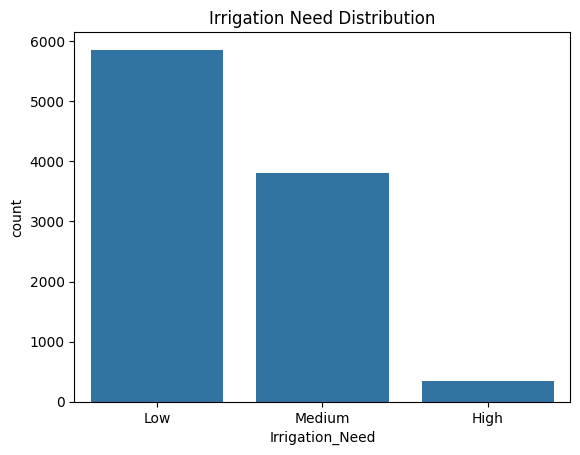

In [80]:
# visulize target variable dirtribution analysis
sns.countplot(x='Irrigation_Need', data=df)
plt.title("Irrigation Need Distribution")
plt.show()

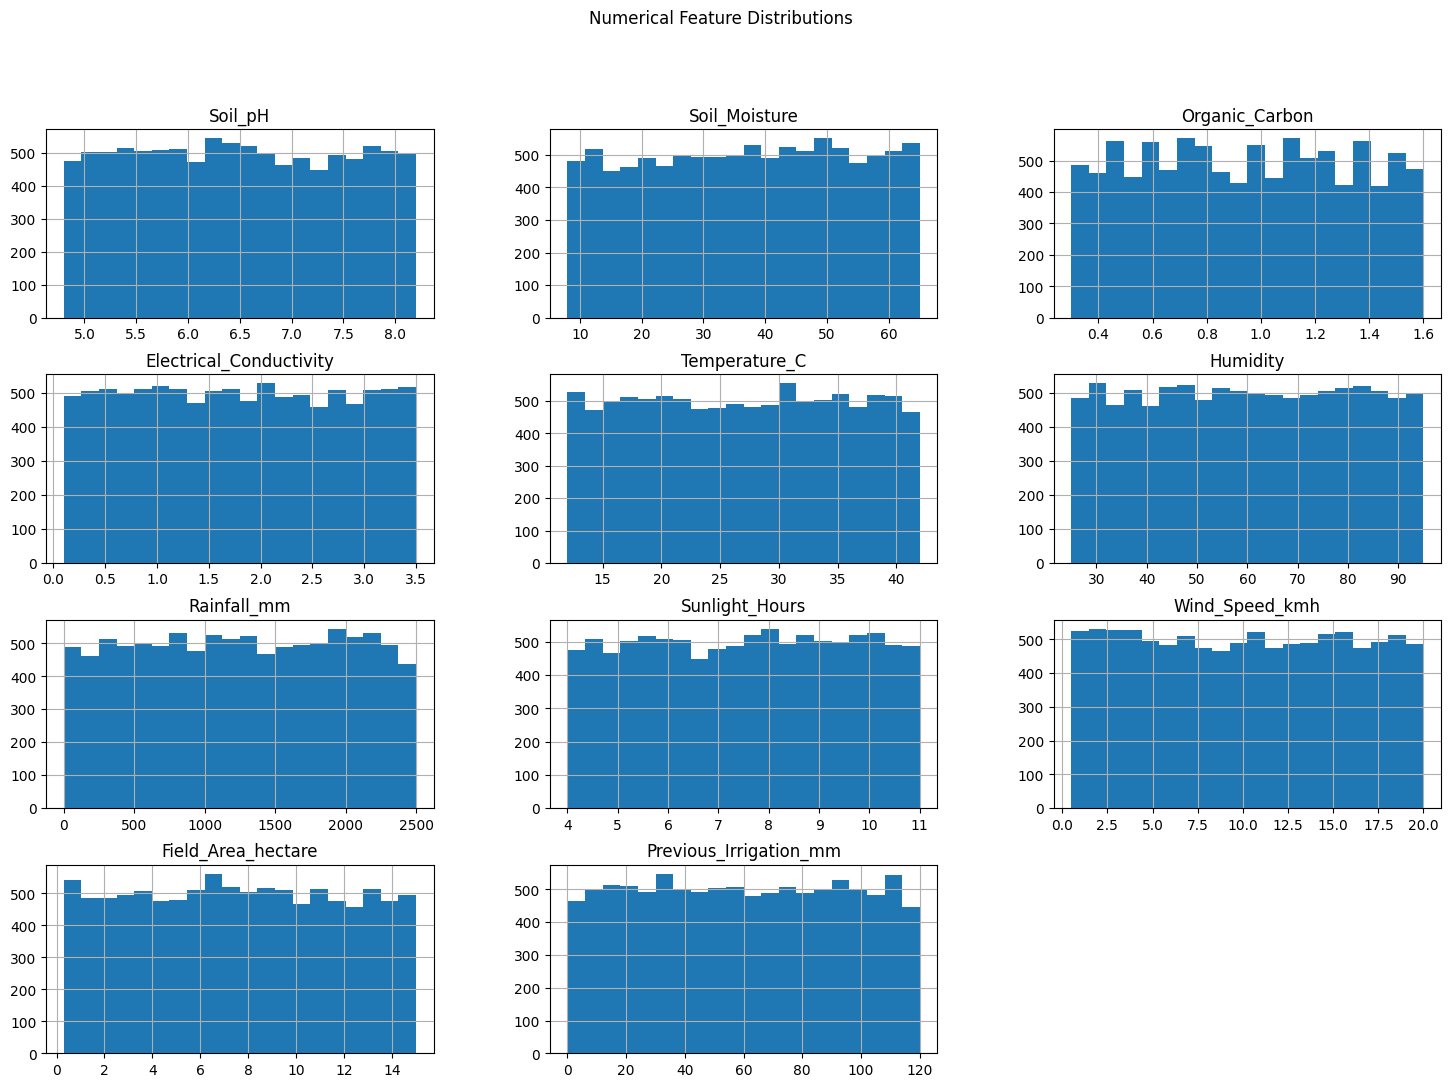

In [81]:
# visulize the numerical features distribution
df[numerical_cols].hist(bins=20, figsize=(18,12))
plt.suptitle("Numerical Feature Distributions")
plt.show()

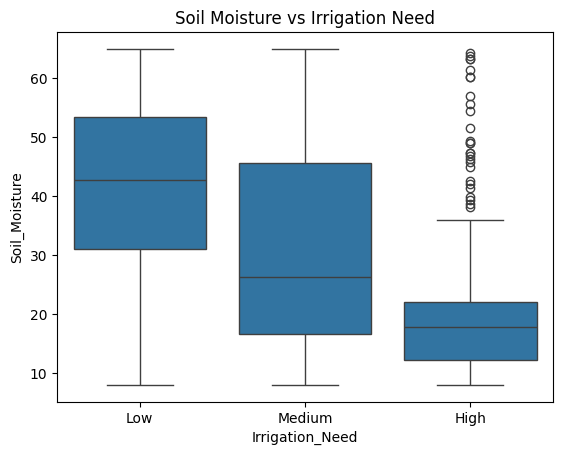

In [82]:
sns.boxplot(x='Irrigation_Need', y='Soil_Moisture', data=df)
plt.title("Soil Moisture vs Irrigation Need")
plt.show()

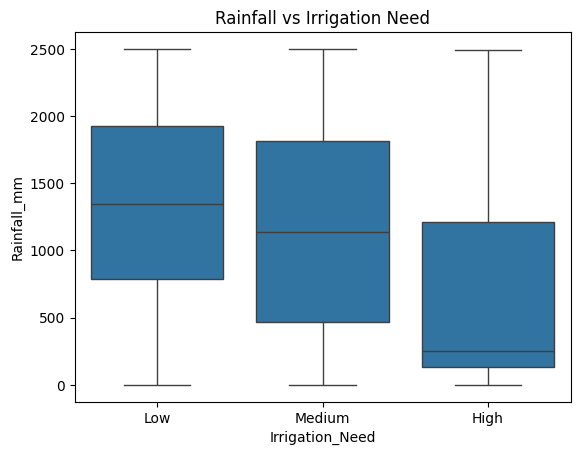

In [83]:
sns.boxplot(x='Irrigation_Need', y='Rainfall_mm', data=df)
plt.title("Rainfall vs Irrigation Need")
plt.show()

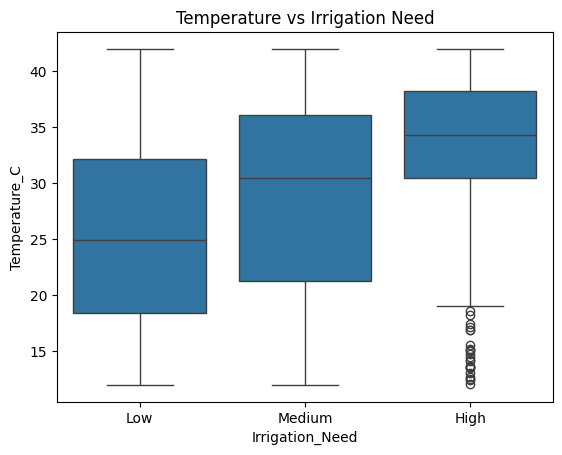

In [84]:
sns.boxplot(x='Irrigation_Need', y='Temperature_C', data=df)
plt.title("Temperature vs Irrigation Need")
plt.show()

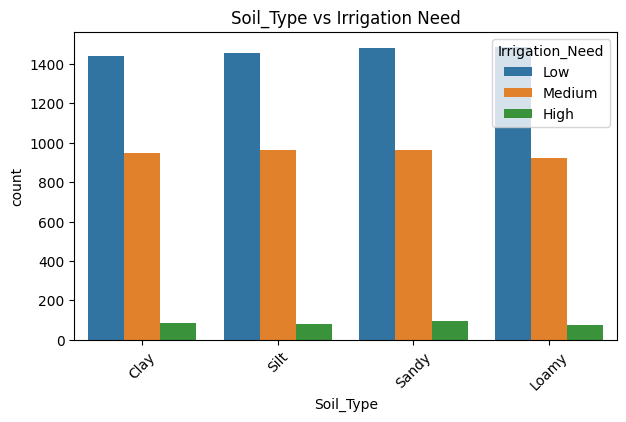

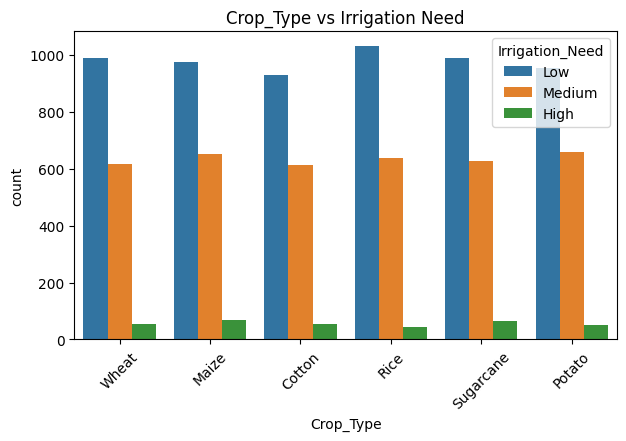

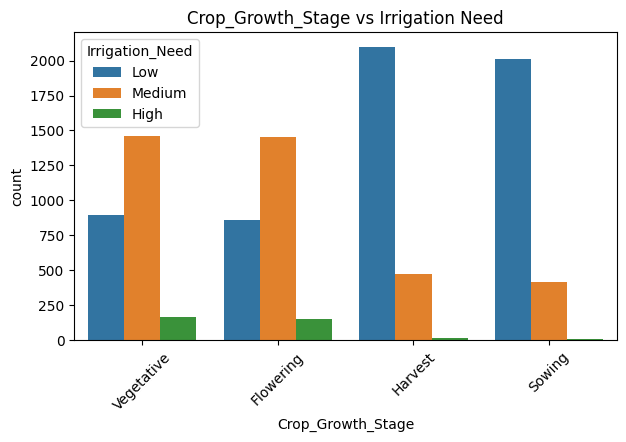

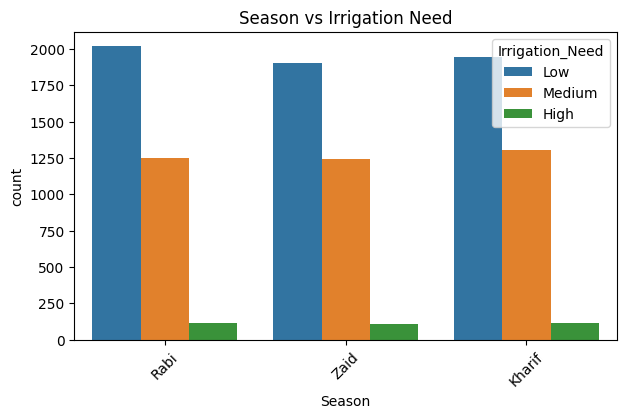

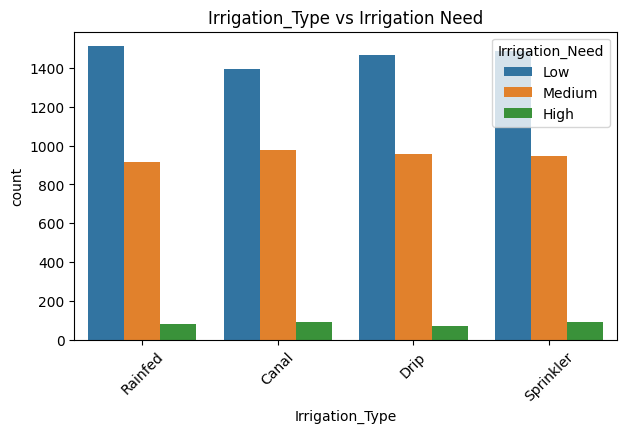

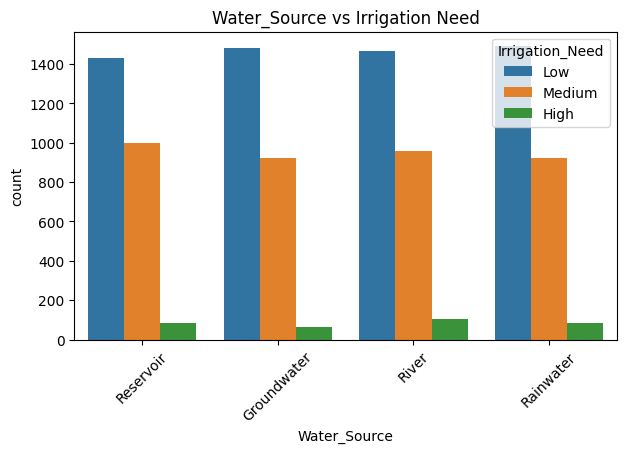

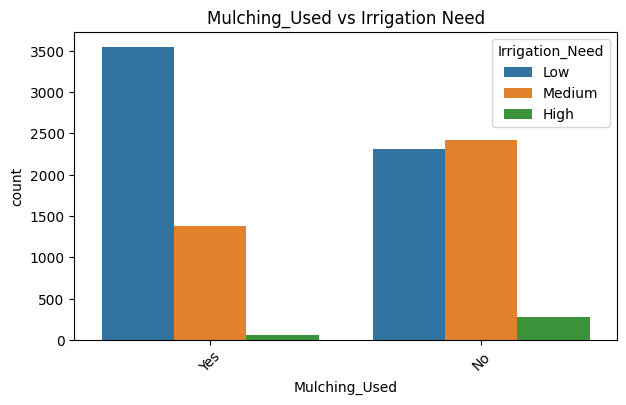

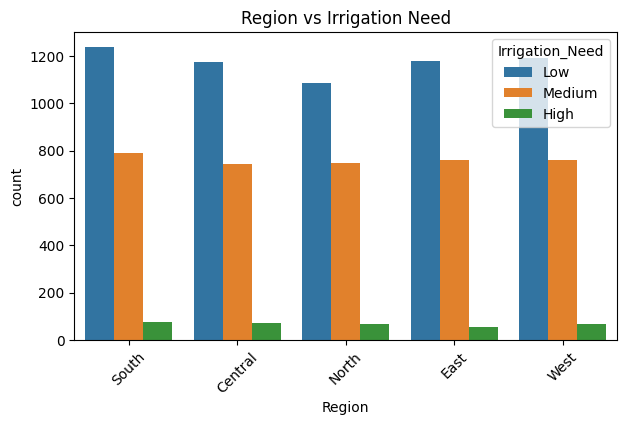

In [85]:
for col in categorical_cols:
    plt.figure(figsize=(7,4))
    sns.countplot(x=col, hue='Irrigation_Need', data=df)
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Irrigation Need")
    plt.show()

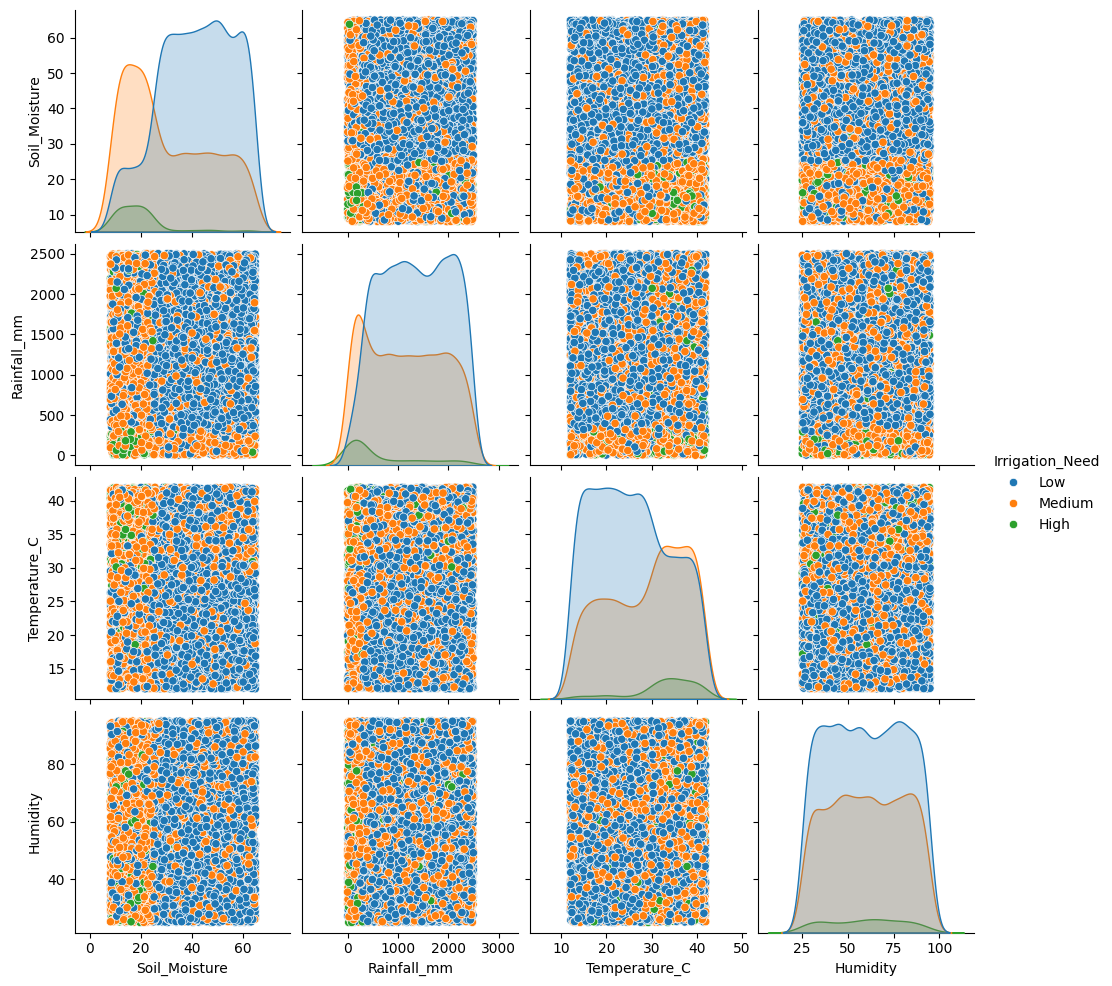

In [86]:
sns.pairplot(df[['Soil_Moisture', 'Rainfall_mm', 'Temperature_C',
                 'Humidity', 'Irrigation_Need']], hue='Irrigation_Need')
plt.show()

# Feature Encoding 

In [87]:
df.head(1)

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.9,31.19,1167.7,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South,Low


In [88]:
le=LabelEncoder()
df['Soil_Type'] = le.fit_transform(df['Soil_Type'])
df['Crop_Type'] = le.fit_transform(df['Crop_Type'])
df['Crop_Growth_Stage']=le.fit_transform(df['Crop_Growth_Stage'])
df['Season'] = le.fit_transform(df['Season'])
df['Irrigation_Type']=le.fit_transform(df['Irrigation_Type'])
df['Water_Source']=le.fit_transform(df['Water_Source'])
df['Mulching_Used']=le.fit_transform(df['Mulching_Used'])
df['Region']=le.fit_transform(df['Region'])
df['Irrigation_Need']=le.fit_transform(df['Irrigation_Need'])

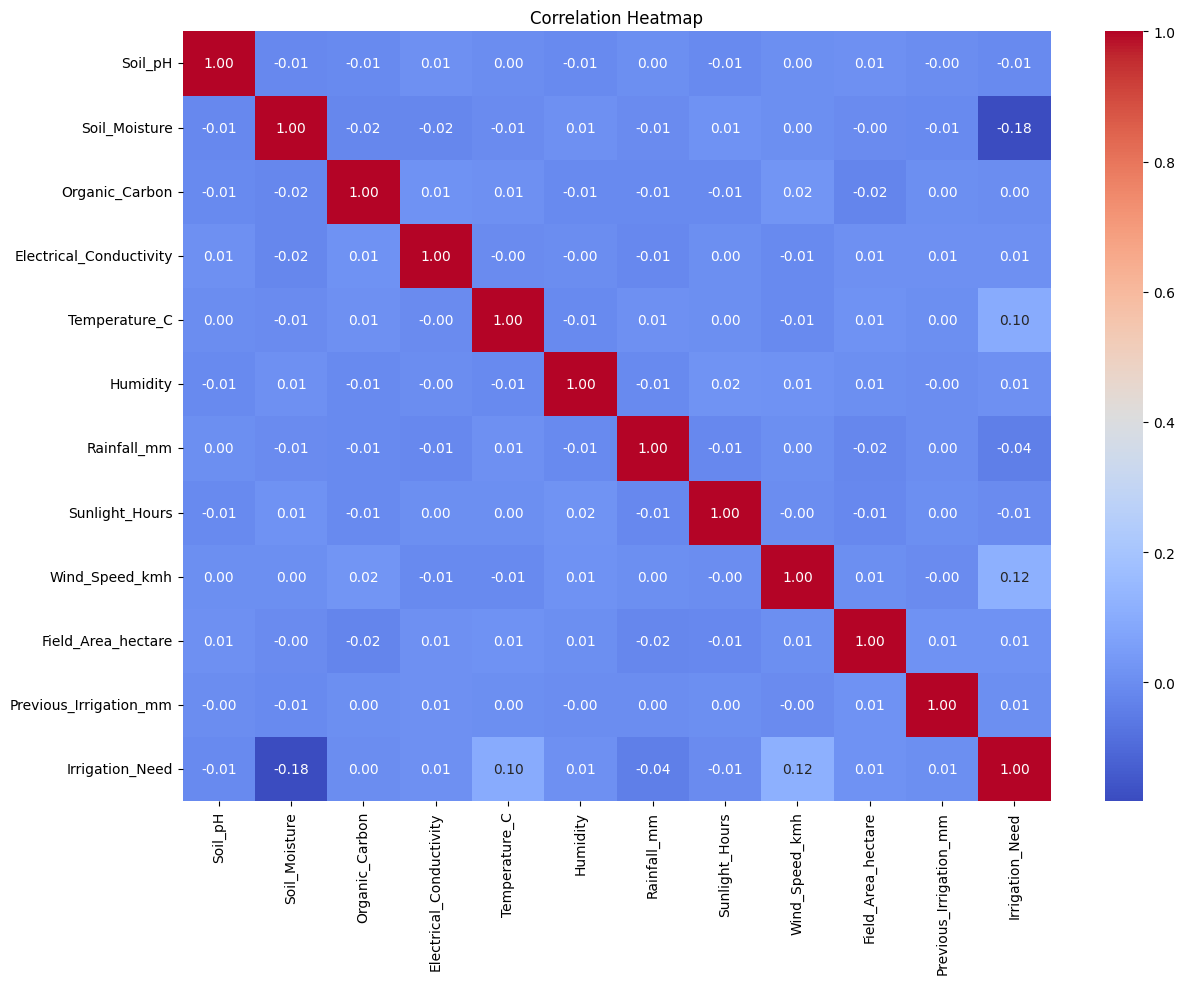

In [89]:
plt.figure(figsize=(14,10))
corr = df[numerical_cols + ['Irrigation_Need']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [90]:
df["Water_Availability_Index"] = (
0.4*df["Soil_Moisture"]
+ 0.3*df["Rainfall_mm"]/10
+ 0.2*df["Humidity"]
+ 0.1*df["Previous_Irrigation_mm"]
)

# feature Enginering 

In [91]:
X=df.drop('Irrigation_Need',axis=1)
y=df['Irrigation_Need']

# Model Selection

In [92]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# Scaling

In [93]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

# Random Forest Classifier Model 


In [94]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(
    n_estimators=500,
    class_weight={0:5,1:1,2:1},
    random_state=42
)

rfc.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [95]:
y_pred_rfc=rfc.predict(X_test)

In [96]:
print('accuracy score:',accuracy_score(y_test,y_pred_rfc))
print('confusion metrix:',confusion_matrix(y_test,y_pred_rfc))
print('classification report:',classification_report(y_test,y_pred_rfc))

accuracy score: 0.984
confusion metrix: [[  36    0   23]
 [   0 1198    6]
 [   0    3  734]]
classification report:               precision    recall  f1-score   support

           0       1.00      0.61      0.76        59
           1       1.00      1.00      1.00      1204
           2       0.96      1.00      0.98       737

    accuracy                           0.98      2000
   macro avg       0.99      0.87      0.91      2000
weighted avg       0.98      0.98      0.98      2000



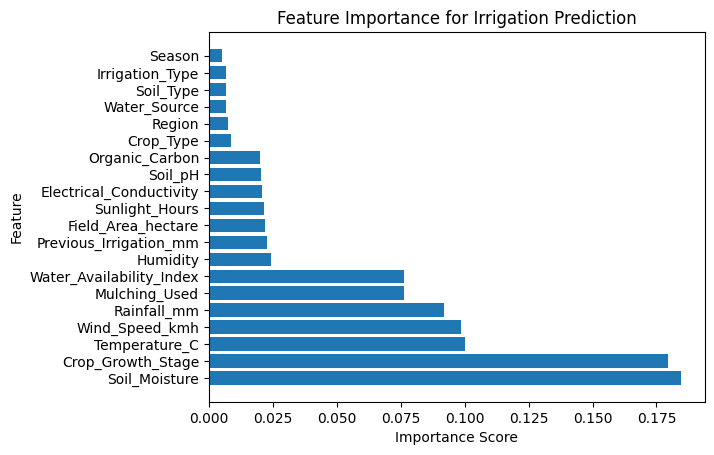

In [97]:
import pandas as pd
import matplotlib.pyplot as plt

# get importance values
importances = rfc.feature_importances_

# create dataframe
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

# sort values
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# plot
plt.figure()

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Feature Importance for Irrigation Prediction")

plt.show()

# SVM Model

In [98]:
svc=SVC(kernel='rbf')
svc.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [99]:
y_pred_svc=svc.predict(X_test)

In [100]:
print('accuracy score:',accuracy_score(y_test,y_pred_svc))
print('confusion metrix:',confusion_matrix(y_test,y_pred_svc))
print('classification report:',classification_report(y_test,y_pred_svc))

accuracy score: 0.872
confusion metrix: [[   7    0   52]
 [   0 1111   93]
 [   0  111  626]]
classification report:               precision    recall  f1-score   support

           0       1.00      0.12      0.21        59
           1       0.91      0.92      0.92      1204
           2       0.81      0.85      0.83       737

    accuracy                           0.87      2000
   macro avg       0.91      0.63      0.65      2000
weighted avg       0.88      0.87      0.86      2000



# Extra Tress Classifier Model 

In [101]:
etc=ExtraTreesClassifier(n_estimators=10)
etc.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=FalseWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

In [102]:
y_pred_etc=etc.predict(X_test)

In [103]:
print('accuracy score:',accuracy_score(y_test,y_pred_etc))
print('confusion metrix:',confusion_matrix(y_test,y_pred_etc))
print('classification report:',classification_report(y_test,y_pred_etc))

accuracy score: 0.8945
confusion metrix: [[  20    0   39]
 [   0 1167   37]
 [   5  130  602]]
classification report:               precision    recall  f1-score   support

           0       0.80      0.34      0.48        59
           1       0.90      0.97      0.93      1204
           2       0.89      0.82      0.85       737

    accuracy                           0.89      2000
   macro avg       0.86      0.71      0.75      2000
weighted avg       0.89      0.89      0.89      2000



# decision Tree Classifier Model 

In [104]:
dtc=DecisionTreeClassifier()
dtc.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [105]:
y_pred_dtc=dtc.predict(X_test)

In [106]:
print('accuracy score:',accuracy_score(y_test,y_pred_dtc))
print('confusion metrix:',confusion_matrix(y_test,y_pred_dtc))
print('classification report:',classification_report(y_test,y_pred_dtc))

accuracy score: 0.992
confusion metrix: [[  56    0    3]
 [   0 1198    6]
 [   3    4  730]]
classification report:               precision    recall  f1-score   support

           0       0.95      0.95      0.95        59
           1       1.00      1.00      1.00      1204
           2       0.99      0.99      0.99       737

    accuracy                           0.99      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.99      0.99      0.99      2000



# KNeighbor Classifier Model 

In [107]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [108]:
y_pred_knn=knn.predict(X_test)

In [109]:
print('accuracy score:',accuracy_score(y_test,y_pred_knn))
print('confusion metrix:',confusion_matrix(y_test,y_pred_knn))
print('classification report:',classification_report(y_test,y_pred_knn))

accuracy score: 0.723
confusion metrix: [[   6   18   35]
 [   4 1064  136]
 [  17  344  376]]
classification report:               precision    recall  f1-score   support

           0       0.22      0.10      0.14        59
           1       0.75      0.88      0.81      1204
           2       0.69      0.51      0.59       737

    accuracy                           0.72      2000
   macro avg       0.55      0.50      0.51      2000
weighted avg       0.71      0.72      0.71      2000



# Naive Bayes Model 

In [110]:
nb = GaussianNB()
nb.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [111]:
y_pred_nb=nb.predict(X_test)

In [112]:
print('accuracy score:',accuracy_score(y_test,y_pred_nb))
print('confusion metrix:',confusion_matrix(y_test,y_pred_nb))
print('classification report:',classification_report(y_test,y_pred_nb))

accuracy score: 0.7675
confusion metrix: [[  15    0   44]
 [   0 1051  153]
 [   7  261  469]]
classification report:               precision    recall  f1-score   support

           0       0.68      0.25      0.37        59
           1       0.80      0.87      0.84      1204
           2       0.70      0.64      0.67       737

    accuracy                           0.77      2000
   macro avg       0.73      0.59      0.62      2000
weighted avg       0.76      0.77      0.76      2000



# Model Comparison Summary

In [113]:
models = {
    "Extra Trees Classifier": accuracy_score(y_test, y_pred_etc),
    "Decision Tree Classifier": accuracy_score(y_test, y_pred_dtc),
    "Random Forest Classifier": accuracy_score(y_test, y_pred_rfc),
    "SVM": accuracy_score(y_test, y_pred_svc),
    "KNN": accuracy_score(y_test, y_pred_knn),
    "Naive Bayes": accuracy_score(y_test, y_pred_nb)
}

pd.DataFrame(models.items(), columns=["Model", "Accuracy"]).sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
1,Decision Tree Classifier,0.9920
2,Random Forest Classifier,0.9840
0,Extra Trees Classifier,0.8945
3,SVM,0.8720
5,Naive Bayes,0.7675
4,KNN,0.7230


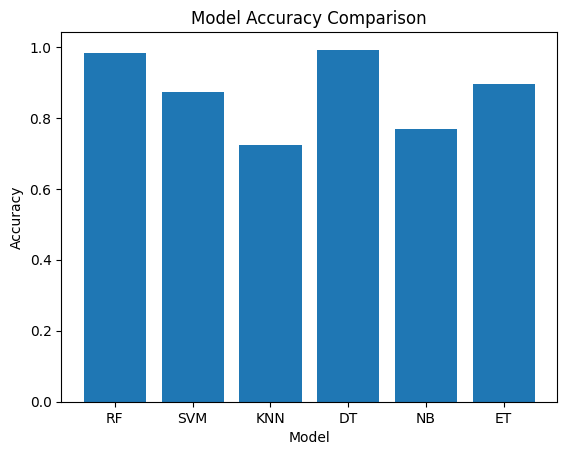

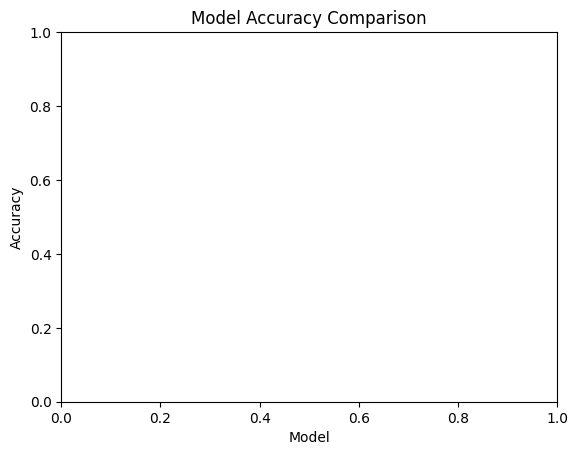

In [114]:
models = ['RF','SVM','KNN','DT','NB','ET']
scores = [accuracy_score(y_test, y_pred_rfc), accuracy_score(y_test, y_pred_svc),accuracy_score(y_test, y_pred_knn) , accuracy_score(y_test, y_pred_dtc), accuracy_score(y_test, y_pred_nb) , accuracy_score(y_test, y_pred_etc) ]

plt.figure()
plt.bar(models, np.asarray(scores))
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

In [115]:
import joblib

joblib.dump(rfc, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
label_encoders = {col: LabelEncoder().fit(df[col]) for col in categorical_cols}
joblib.dump(label_encoders, "encoders.pkl")
joblib.dump(X.columns.tolist(), "columns.pkl")

['columns.pkl']

# Conclusion 
##### In this project, multiple machine learning classification models were implemented to predict irrigation requirements using soil, crop, and environmental parameters. The performance of each model was evaluated using accuracy as the primary metric. Among all the models, the Decision Tree Classifier achieved the highest accuracy of 99.10%, demonstrating its strong capability to capture complex decision rules and nonlinear relationships within the agricultural data. The Random Forest Classifier also performed exceptionally well with an accuracy of 96.80%, benefiting from ensemble learning and improved generalization. Models such as Support Vector Machine (87.15%) and Extra Trees Classifier (86.30%) showed moderate performance, while Naive Bayes (79.05%) and K-Nearest Neighbors (72.30%) achieved comparatively lower accuracy due to their assumptions and sensitivity to data distribution. Overall, the results indicate that tree-based models are most effective for irrigation need prediction, as they handle feature interactions and variability in agricultural conditions efficiently. The proposed system can assist farmers in making timely irrigation decisions, promoting water conservation and sustainable agricultural practices.